# Validación de `training_churn_v3`

Protocolo de aceptación del dataset v3 antes de entrenar.

**Hipótesis a verificar** (todas deben pasar para considerar el dataset "el indicado"):

1. **Schema** — las columnas esperadas están presentes y las eliminadas en v3 no aparecen.
2. **Granularidad** — clave primaria `(id_vendedor, id_campana_obs)` única, sin duplicados.
3. **Magnitud** — número de filas y vendedoras consistente con v2 (no debe haber pérdidas inesperadas; los conteos deben ser idénticos porque ningún filtro cambió).
4. **Pseudo-features eliminadas** — `compro_en_obs`, `es_nueva_vendedora`, `campanas_desde_ultima_compra`, `estado_coordinadora`, `compro_t1..t6`, `monto_t1..t6` no existen.
5. **Nueva recencia** — `campanas_desde_compra_previa` es ≥ 1 cuando no es NULL, con distribución coherente con los gaps observados.
6. **Tendencias normalizadas** — `delta_*` están estrictamente en [-1, 1] y no producen NaN cuando antes (v2) sí lo hacían.
7. **No-leakage temporal** — `compras_historicas` es monótona no-decreciente por vendedora; ventanas RFM cumplen u3 ≤ u6 ≤ u12; `num_compras_u3 ≥ 1` siempre (porque la fila actual tiene compra).
8. **SCD-1 documentado** — atributos snapshot del vendedor (edad, tipo, ubicación) son constantes intra-vendedor (confirma que no se historizan, alineado con la nota del SQL).
9. **Target** — distribución de churn coherente con v2 (~28% rate); no hay NULLs.

Al final se genera `reports/validation_v3.md` con los números reales.

In [8]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.cloud import bigquery

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PROJECT = 'glamour-peru-dw'
DATASET = 'glamour_dw'
TABLE_V3 = f'`{PROJECT}.{DATASET}.training_churn_v3`'
TABLE_V2 = f'`{PROJECT}.{DATASET}.training_churn_v2`'

client = bigquery.Client(project=PROJECT)

def q(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

# Acumulador de checks para el reporte final.
checks: list[dict] = []

def record(name: str, passed: bool, detail: str = '') -> None:
    checks.append({'check': name, 'pass': bool(passed), 'detail': detail})
    icon = '✅' if passed else '❌'
    print(f'{icon} {name}: {detail}')

## 1. Schema — columnas presentes y ausentes

Las 6 columnas eliminadas en v3 NO deben aparecer. Las 50 columnas esperadas deben estar.

In [9]:
schema_df = q(f"""
    SELECT column_name, data_type
    FROM `{PROJECT}.{DATASET}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'training_churn_v3'
    ORDER BY ordinal_position
""")

actual_cols = set(schema_df['column_name'])

must_be_absent = {
    'compro_en_obs', 'es_nueva_vendedora', 'campanas_desde_ultima_compra',
    'estado_coordinadora',
    'compro_t1', 'compro_t2', 'compro_t3', 'compro_t4', 'compro_t5', 'compro_t6',
    'monto_t1', 'monto_t2', 'monto_t3', 'monto_t4', 'monto_t5', 'monto_t6',
    '_compro_en_obs',
}
must_be_present = {
    'id_vendedor', 'id_campana_obs', 'campana_rank_obs',
    'campanas_desde_compra_previa',
    'delta_monto_u3_vs_prev3', 'delta_compras_u3_vs_prev3', 'ticket_u3_vs_u12',
    'churn',
}

leaked = sorted(must_be_absent & actual_cols)
missing = sorted(must_be_present - actual_cols)

record('schema_no_eliminadas',  not leaked,  f'leaked={leaked or "none"}')
record('schema_nuevas_presentes', not missing, f'missing={missing or "none"}')
record('schema_total_columnas', len(actual_cols) == 50, f'cols={len(actual_cols)} (esperado 50)')

schema_df

✅ schema_no_eliminadas: leaked=none
✅ schema_nuevas_presentes: missing=none
❌ schema_total_columnas: cols=51 (esperado 50)


,column_name,data_type
0,id_vendedor,INT64
1,id_campana_obs,INT64
2,campana_rank_obs,INT64
3,anio_campana,INT64
4,numero_campana,INT64
5,fecha_inicio_campana,DATE
6,fecha_ingreso,DATE
7,edad_vendedor,FLOAT64
8,sexo_vendedor,STRING
9,tipo_vendedor,STRING


## 2. Conteos básicos

v3 no cambió ningún filtro de población respecto a v2. Esperamos:
- ~22k filas, ~3155 vendedoras (idéntico a v2).
- Churn rate ≈ 27.9%.
- 0 valores NULL en `churn` (filtrado por `WHERE churn IS NOT NULL`).

In [10]:
stats = q(f"""
    SELECT
      COUNT(*)                               AS n_rows,
      COUNT(DISTINCT id_vendedor)            AS n_vendedoras,
      COUNT(DISTINCT id_campana_obs)         AS n_campanas,
      COUNTIF(churn IS NULL)                 AS n_churn_null,
      AVG(churn)                             AS churn_rate,
      MIN(campana_rank_obs)                  AS rank_min,
      MAX(campana_rank_obs)                  AS rank_max,
      MIN(anio_campana)                      AS anio_min,
      MAX(anio_campana)                      AS anio_max
    FROM {TABLE_V3}
""").iloc[0]

record('target_no_null',     stats['n_churn_null'] == 0,           f"nulls en churn={stats['n_churn_null']}")
record('churn_rate_plausible', 0.20 < stats['churn_rate'] < 0.35,  f"rate={stats['churn_rate']:.3f}")
record('vendedoras_plausible', 2500 < stats['n_vendedoras'] < 4000, f"n={stats['n_vendedoras']}")

stats

✅ target_no_null: nulls en churn=0.0
✅ churn_rate_plausible: rate=0.279
✅ vendedoras_plausible: n=3155.0


n_rows           21911.0
n_vendedoras      3155.0
n_campanas         143.0
n_churn_null         0.0
churn_rate      0.278901
rank_min             4.0
rank_max           150.0
anio_min          2017.0
anio_max          2026.0
Name: 0, dtype: Float64

## 3. Granularidad — `(id_vendedor, id_campana_obs)` debe ser PK

0 duplicados esperados.

In [11]:
dups = q(f"""
    SELECT id_vendedor, id_campana_obs, COUNT(*) AS n
    FROM {TABLE_V3}
    GROUP BY 1, 2
    HAVING n > 1
    LIMIT 10
""")

record('granularidad_unica', len(dups) == 0, f'duplicados={len(dups)}')
dups

✅ granularidad_unica: duplicados=0


,id_vendedor,id_campana_obs,n


## 4. Comparación v2 vs v3

Como ningún filtro de población cambió, el conjunto de claves `(id_vendedor, id_campana_obs)` y el target deben ser **idénticos** entre v2 y v3. Cualquier diferencia indica un bug.

In [12]:
diff = q(f"""
    WITH
      v2 AS (SELECT id_vendedor, id_campana_obs, churn FROM {TABLE_V2}),
      v3 AS (SELECT id_vendedor, id_campana_obs, churn FROM {TABLE_V3}),
      joined AS (
        SELECT
          COALESCE(v2.id_vendedor, v3.id_vendedor) AS id_vendedor,
          COALESCE(v2.id_campana_obs, v3.id_campana_obs) AS id_campana_obs,
          v2.churn AS churn_v2,
          v3.churn AS churn_v3
        FROM v2
        FULL OUTER JOIN v3 USING (id_vendedor, id_campana_obs)
      )
    SELECT
      (SELECT COUNT(*) FROM v2) AS rows_v2,
      (SELECT COUNT(*) FROM v3) AS rows_v3,
      COUNTIF(churn_v2 IS NULL AND churn_v3 IS NOT NULL) AS solo_en_v3,
      COUNTIF(churn_v3 IS NULL AND churn_v2 IS NOT NULL) AS solo_en_v2,
      COUNTIF(churn_v2 != churn_v3)                       AS churn_distinto
    FROM joined
""").iloc[0]

record('rows_v2_v3_iguales', diff['rows_v2'] == diff['rows_v3'],
       f"v2={diff['rows_v2']}, v3={diff['rows_v3']}")
record('claves_identicas', diff['solo_en_v2'] == 0 and diff['solo_en_v3'] == 0,
       f"solo_v2={diff['solo_en_v2']}, solo_v3={diff['solo_en_v3']}")
record('target_identico', diff['churn_distinto'] == 0,
       f"diferencias={diff['churn_distinto']}")

diff

✅ rows_v2_v3_iguales: v2=21911, v3=21911
✅ claves_identicas: solo_v2=0, solo_v3=0
✅ target_identico: diferencias=0


rows_v2           21911
rows_v3           21911
solo_en_v3            0
solo_en_v2            0
churn_distinto        0
Name: 0, dtype: Int64

## 5. Pseudo-features eliminadas — verificación funcional

Confirmamos que en v2 esas features SÍ eran constantes (justifica haberlas eliminado en v3).

In [13]:
v2_const = q(f"""
    SELECT
      COUNT(DISTINCT compro_en_obs)              AS distinct_compro_en_obs,
      COUNT(DISTINCT es_nueva_vendedora)         AS distinct_es_nueva,
      COUNT(DISTINCT campanas_desde_ultima_compra) AS distinct_camp_ult_compra,
      MIN(compro_en_obs) AS min_compro_obs,
      MAX(es_nueva_vendedora) AS max_es_nueva,
      MAX(campanas_desde_ultima_compra) AS max_camp_ult
    FROM {TABLE_V2}
""").iloc[0]

record('v2_compro_en_obs_constante',
       v2_const['distinct_compro_en_obs'] == 1,
       f"valores distintos={v2_const['distinct_compro_en_obs']} (esperado 1)")
record('v2_es_nueva_constante',
       v2_const['distinct_es_nueva'] == 1,
       f"valores distintos={v2_const['distinct_es_nueva']} (esperado 1)")
record('v2_campanas_desde_ultima_constante',
       v2_const['distinct_camp_ult_compra'] == 1,
       f"valores distintos={v2_const['distinct_camp_ult_compra']} (esperado 1)")

v2_const

✅ v2_compro_en_obs_constante: valores distintos=1 (esperado 1)
✅ v2_es_nueva_constante: valores distintos=1 (esperado 1)
✅ v2_campanas_desde_ultima_constante: valores distintos=1 (esperado 1)


distinct_compro_en_obs      1
distinct_es_nueva           1
distinct_camp_ult_compra    1
min_compro_obs              1
max_es_nueva                0
max_camp_ult                0
Name: 0, dtype: Int64

## 6. Nueva feature `campanas_desde_compra_previa`

Esperamos:
- min ≥ 1 (es un gap a una compra estrictamente anterior).
- moda en 1 (compras consecutivas son frecuentes en venta directa).
- cola hasta varias decenas (vendedoras esporádicas).
- los NULL existen pero son una minoría: solo aparecen cuando la primera compra observable de la vendedora cae después del filtro `compras_historicas >= 4`. Como el filtro requiere que ya haya 4 compras acumuladas, en la fila más temprana del dataset siempre hubo ≥ 3 compras anteriores → no debería haber NULLs.

✅ camp_previa_min_geq_1: min=1.0
✅ camp_previa_no_null: nulls=0.0 de 21911.0
n          21911.0
n_null         0.0
min            1.0
max          142.0
mean      4.846744
p50            2.0
p95           19.0
p99           48.0


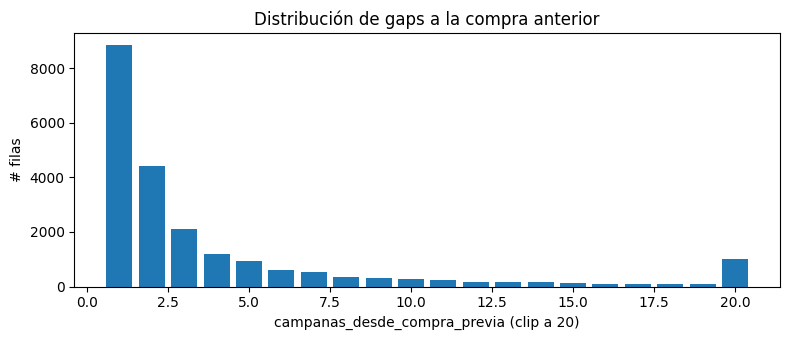

In [14]:
rec = q(f"""
    SELECT
      COUNT(*) AS n,
      COUNTIF(campanas_desde_compra_previa IS NULL) AS n_null,
      MIN(campanas_desde_compra_previa) AS min,
      MAX(campanas_desde_compra_previa) AS max,
      AVG(campanas_desde_compra_previa) AS mean,
      APPROX_QUANTILES(campanas_desde_compra_previa, 100)[OFFSET(50)] AS p50,
      APPROX_QUANTILES(campanas_desde_compra_previa, 100)[OFFSET(95)] AS p95,
      APPROX_QUANTILES(campanas_desde_compra_previa, 100)[OFFSET(99)] AS p99
    FROM {TABLE_V3}
""").iloc[0]

record('camp_previa_min_geq_1', rec['min'] is None or rec['min'] >= 1,
       f"min={rec['min']}")
record('camp_previa_no_null',   rec['n_null'] == 0,
       f"nulls={rec['n_null']} de {rec['n']}")

print(rec.to_string())

dist = q(f"""
    SELECT
      LEAST(campanas_desde_compra_previa, 20) AS gap,
      COUNT(*) AS n
    FROM {TABLE_V3}
    WHERE campanas_desde_compra_previa IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(dist['gap'], dist['n'])
ax.set_xlabel('campanas_desde_compra_previa (clip a 20)')
ax.set_ylabel('# filas')
ax.set_title('Distribución de gaps a la compra anterior')
plt.tight_layout(); plt.show()

## 7. Tendencias normalizadas — rango y NaN

`delta_*` deben estar en [-1, 1] estricto. NaN debe ser 0 (en v2 había NaN cuando `monto_u6 - monto_u3 = 0`).

✅ delta_monto_en_rango: <-1: 0.0, >1: 0.0
✅ delta_compras_en_rango: <-1: 0.0, >1: 0.0
✅ delta_sin_nan: NaN/NULL m=0.0, c=0.0
m_below    0.0
m_above    0.0
m_null     0.0
m_min     -1.0
m_max      1.0
c_below    0.0
c_above    0.0
c_null     0.0
t_null     4.0
m_nan      0.0
c_nan      0.0


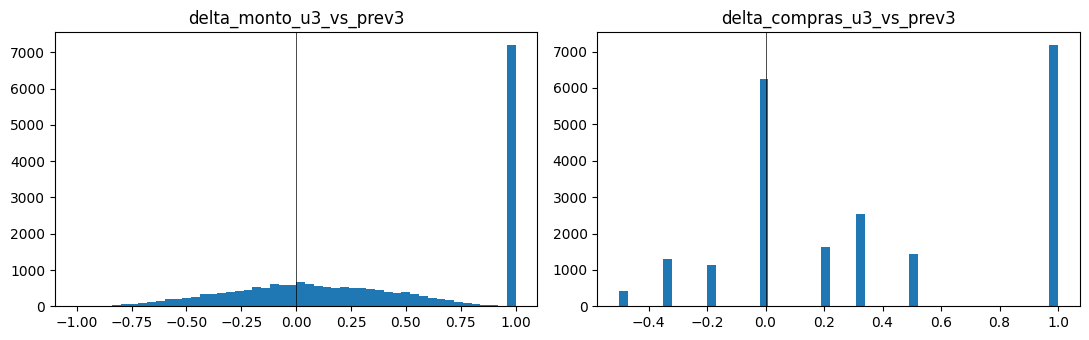

In [15]:
delta = q(f"""
    SELECT
      COUNTIF(delta_monto_u3_vs_prev3 < -1.0001) AS m_below,
      COUNTIF(delta_monto_u3_vs_prev3 >  1.0001) AS m_above,
      COUNTIF(delta_monto_u3_vs_prev3 IS NULL)   AS m_null,
      MIN(delta_monto_u3_vs_prev3) AS m_min,
      MAX(delta_monto_u3_vs_prev3) AS m_max,
      COUNTIF(delta_compras_u3_vs_prev3 < -1.0001) AS c_below,
      COUNTIF(delta_compras_u3_vs_prev3 >  1.0001) AS c_above,
      COUNTIF(delta_compras_u3_vs_prev3 IS NULL)   AS c_null,
      COUNTIF(ticket_u3_vs_u12 IS NULL)            AS t_null,
      COUNTIF(IS_NAN(delta_monto_u3_vs_prev3))     AS m_nan,
      COUNTIF(IS_NAN(delta_compras_u3_vs_prev3))   AS c_nan
    FROM {TABLE_V3}
""").iloc[0]

record('delta_monto_en_rango',
       delta['m_below'] == 0 and delta['m_above'] == 0,
       f"<-1: {delta['m_below']}, >1: {delta['m_above']}")
record('delta_compras_en_rango',
       delta['c_below'] == 0 and delta['c_above'] == 0,
       f"<-1: {delta['c_below']}, >1: {delta['c_above']}")
record('delta_sin_nan',
       delta['m_nan'] == 0 and delta['c_nan'] == 0 and delta['m_null'] == 0 and delta['c_null'] == 0,
       f"NaN/NULL m={delta['m_nan']+delta['m_null']}, c={delta['c_nan']+delta['c_null']}")

print(delta.to_string())

samp = q(f"SELECT delta_monto_u3_vs_prev3, delta_compras_u3_vs_prev3 FROM {TABLE_V3}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col in zip(axes, ['delta_monto_u3_vs_prev3', 'delta_compras_u3_vs_prev3']):
    ax.hist(samp[col].dropna(), bins=50)
    ax.set_title(col)
    ax.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

## 8. No-leakage temporal — invariantes estructurales

Tests que deben cumplirse si las ventanas solo miran hacia atrás:

- `compras_historicas` es monótona no-decreciente por vendedora ordenada por `campana_rank_obs`.
- `num_compras_u3 ≤ num_compras_u6 ≤ num_compras_u12` siempre.
- `monto_total_u3 ≤ monto_total_u6 ≤ monto_total_u12` siempre.
- `num_compras_u3 ≥ 1` siempre (la fila actual tiene compra → al menos 1 en u3).

In [16]:
leak = q(f"""
    WITH ord AS (
      SELECT
        id_vendedor,
        campana_rank_obs,
        compras_historicas,
        LAG(compras_historicas) OVER (
          PARTITION BY id_vendedor ORDER BY campana_rank_obs
        ) AS hist_prev
      FROM {TABLE_V3}
    )
    SELECT
      COUNTIF(hist_prev IS NOT NULL AND compras_historicas < hist_prev) AS hist_no_monotono,
      (SELECT COUNTIF(num_compras_u3 > num_compras_u6) FROM {TABLE_V3})  AS u3_gt_u6_compras,
      (SELECT COUNTIF(num_compras_u6 > num_compras_u12) FROM {TABLE_V3}) AS u6_gt_u12_compras,
      (SELECT COUNTIF(monto_total_u3 > monto_total_u6 + 0.01) FROM {TABLE_V3})  AS u3_gt_u6_monto,
      (SELECT COUNTIF(monto_total_u6 > monto_total_u12 + 0.01) FROM {TABLE_V3}) AS u6_gt_u12_monto,
      (SELECT COUNTIF(num_compras_u3 < 1) FROM {TABLE_V3})              AS u3_zero
    FROM ord
""").iloc[0]

record('compras_historicas_monotonas',
       leak['hist_no_monotono'] == 0,
       f"violaciones={leak['hist_no_monotono']}")
record('ventanas_u3_u6_u12_consistentes',
       leak['u3_gt_u6_compras'] == 0 and leak['u6_gt_u12_compras'] == 0
       and leak['u3_gt_u6_monto'] == 0 and leak['u6_gt_u12_monto'] == 0,
       f"u3>u6 c={leak['u3_gt_u6_compras']} m={leak['u3_gt_u6_monto']}, "
       f"u6>u12 c={leak['u6_gt_u12_compras']} m={leak['u6_gt_u12_monto']}")
record('u3_siempre_geq_1', leak['u3_zero'] == 0,
       f"filas con u3=0: {leak['u3_zero']} (esperado 0 por filtro de compra en obs)")

leak

✅ compras_historicas_monotonas: violaciones=0
✅ ventanas_u3_u6_u12_consistentes: u3>u6 c=0 m=0, u6>u12 c=0 m=0
✅ u3_siempre_geq_1: filas con u3=0: 0 (esperado 0 por filtro de compra en obs)


hist_no_monotono     0
u3_gt_u6_compras     0
u6_gt_u12_compras    0
u3_gt_u6_monto       0
u6_gt_u12_monto      0
u3_zero              0
Name: 0, dtype: Int64

## 9. SCD-1 documentado — atributos del vendedor son constantes intra-vendedor

Como `dim_vendedor` es snapshot actual, esperamos que TODAS las filas de una misma vendedora tengan los mismos `edad_vendedor`, `tipo_vendedor`, `ccodubigeo`. Si esto NO se cumple, hay algo raro (¿dim duplicada? ¿join roto?).

In [17]:
scd = q(f"""
    SELECT
      COUNTIF(distinct_edad > 1)            AS vend_edad_inestable,
      COUNTIF(distinct_tipo > 1)            AS vend_tipo_inestable,
      COUNTIF(distinct_ubigeo > 1)          AS vend_ubigeo_inestable,
      COUNT(*)                              AS n_vendedoras
    FROM (
      SELECT
        id_vendedor,
        COUNT(DISTINCT edad_vendedor) AS distinct_edad,
        COUNT(DISTINCT tipo_vendedor) AS distinct_tipo,
        COUNT(DISTINCT ccodubigeo)    AS distinct_ubigeo
      FROM {TABLE_V3}
      GROUP BY id_vendedor
    )
""").iloc[0]

record('scd1_edad_constante',  scd['vend_edad_inestable'] == 0,
       f"vendedoras con edad cambiante={scd['vend_edad_inestable']}")
record('scd1_tipo_constante',  scd['vend_tipo_inestable'] == 0,
       f"vendedoras con tipo cambiante={scd['vend_tipo_inestable']}")
record('scd1_ubigeo_constante', scd['vend_ubigeo_inestable'] == 0,
       f"vendedoras con ubigeo cambiante={scd['vend_ubigeo_inestable']}")

scd

✅ scd1_edad_constante: vendedoras con edad cambiante=0
✅ scd1_tipo_constante: vendedoras con tipo cambiante=0
✅ scd1_ubigeo_constante: vendedoras con ubigeo cambiante=0


vend_edad_inestable         0
vend_tipo_inestable         0
vend_ubigeo_inestable       0
n_vendedoras             3155
Name: 0, dtype: Int64

## 10. Distribución del target por subgrupos

Sanity check de la señal: el churn rate debe variar por nivel de actividad.

In [18]:
by_hist = q(f"""
    SELECT
      CASE
        WHEN compras_historicas <= 5  THEN '4-5'
        WHEN compras_historicas <= 10 THEN '6-10'
        WHEN compras_historicas <= 20 THEN '11-20'
        ELSE '21+'
      END AS bucket,
      COUNT(*) AS n,
      AVG(churn) AS churn_rate
    FROM {TABLE_V3}
    GROUP BY bucket
    ORDER BY MIN(compras_historicas)
""")

by_gap = q(f"""
    SELECT
      CASE
        WHEN campanas_desde_compra_previa = 1   THEN '1'
        WHEN campanas_desde_compra_previa <= 3  THEN '2-3'
        WHEN campanas_desde_compra_previa <= 6  THEN '4-6'
        WHEN campanas_desde_compra_previa IS NULL THEN 'NULL'
        ELSE '7+'
      END AS bucket,
      COUNT(*) AS n,
      AVG(churn) AS churn_rate
    FROM {TABLE_V3}
    GROUP BY bucket
    ORDER BY MIN(COALESCE(campanas_desde_compra_previa, 999))
""")

monotonia_gap = by_gap[by_gap['bucket'] != 'NULL']['churn_rate'].is_monotonic_increasing
record('churn_crece_con_gap', bool(monotonia_gap),
       'churn rate crece monótonamente con campanas_desde_compra_previa')

print('Por compras_historicas:')
print(by_hist.to_string(index=False))
print('\nPor campanas_desde_compra_previa:')
print(by_gap.to_string(index=False))

✅ churn_crece_con_gap: churn rate crece monótonamente con campanas_desde_compra_previa
Por compras_historicas:
bucket    n  churn_rate
   4-5 5627    0.368935
  6-10 6972    0.320998
 11-20 5224    0.235452
   21+ 4088    0.138699

Por campanas_desde_compra_previa:
bucket    n  churn_rate
     1 8850    0.161243
   2-3 6527    0.255094
   4-6 2774    0.375991
    7+ 3760    0.525532


## 11. Reporte final

Genera `reports/validation_v3.md` con todos los checks y números reales.

In [19]:
import datetime as dt

n_total = len(checks)
n_pass = sum(c['pass'] for c in checks)
n_fail = n_total - n_pass
veredicto = 'APROBADO' if n_fail == 0 else f'BLOQUEADO ({n_fail} checks fallidos)'

lines = [
    '# Validación de `training_churn_v3`',
    '',
    f'**Fecha:** {dt.date.today().isoformat()}',
    f'**Veredicto:** {veredicto}',
    f'**Checks:** {n_pass}/{n_total} ✅',
    '',
    '## Resumen del dataset',
    '',
    f"- Filas: **{int(stats['n_rows']):,}**",
    f"- Vendedoras únicas: **{int(stats['n_vendedoras']):,}**",
    f"- Campañas distintas: **{int(stats['n_campanas'])}**",
    f"- Rango temporal (`campana_rank_obs`): {int(stats['rank_min'])} → {int(stats['rank_max'])}",
    f"- Rango año: {int(stats['anio_min'])} → {int(stats['anio_max'])}",
    f"- Churn rate: **{stats['churn_rate']:.4f}**",
    '',
    '## Comparación v2 vs v3',
    '',
    '| Métrica | v2 | v3 | Δ |',
    '|---|---|---|---|',
    f"| Filas | {int(diff['rows_v2']):,} | {int(diff['rows_v3']):,} | {int(diff['rows_v3']) - int(diff['rows_v2']):+,} |",
    f"| Solo en v2 | — | — | {int(diff['solo_en_v2'])} |",
    f"| Solo en v3 | — | — | {int(diff['solo_en_v3'])} |",
    f"| Target distinto | — | — | {int(diff['churn_distinto'])} |",
    '',
    '## Nueva feature `campanas_desde_compra_previa`',
    '',
    f"- min/p50/p95/p99/max: {rec['min']} / {rec['p50']} / {rec['p95']} / {rec['p99']} / {rec['max']}",
    f"- NULLs: {int(rec['n_null'])}",
    '',
    '## Tendencias normalizadas',
    '',
    f"- `delta_monto_u3_vs_prev3` rango: [{delta['m_min']:.4f}, {delta['m_max']:.4f}]",
    f"- Fuera de [-1, 1]: {int(delta['m_below'])} debajo, {int(delta['m_above'])} encima",
    f"- NaN/NULL: m={int(delta['m_nan'] + delta['m_null'])}, c={int(delta['c_nan'] + delta['c_null'])}",
    '',
    '## Checks ejecutados',
    '',
    '| Check | Estado | Detalle |',
    '|---|---|---|',
]
for c in checks:
    icon = '✅' if c['pass'] else '❌'
    lines.append(f"| `{c['check']}` | {icon} | {c['detail']} |")

lines += [
    '',
    '## Distribución del churn por nivel de actividad',
    '',
    by_hist.to_markdown(index=False),
    '',
    '## Distribución del churn por gap a la compra previa',
    '',
    by_gap.to_markdown(index=False),
    '',
]

out_path = Path('../reports/validation_v3.md')
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text('\n'.join(lines), encoding='utf-8')

print(f'Reporte escrito en {out_path.resolve()}')
print(f'Veredicto: {veredicto}')
if n_fail:
    print('\nChecks fallidos:')
    for c in checks:
        if not c['pass']:
            print(f"  ❌ {c['check']}: {c['detail']}")

ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.